# DCT-Domain Image Watermarking with Manual JPEG Compression

**Course:** Multimedia Systems

---

This notebook implements a complete digital image watermarking pipeline from scratch. No built-in DCT, JPEG, or watermarking functions are used anywhere. Every step is coded manually using only NumPy, Pillow, and Matplotlib.

**What we do:**

A binary watermark is embedded into a face photo by modifying mid-frequency DCT coefficients in each 8x8 block using Quantization Index Modulation (QIM). The watermarked image is then compressed at various JPEG Quality Factors (QF) using a manually implemented JPEG pipeline. Finally, the watermark is extracted from the compressed image and evaluated using Bit Error Rate (BER) and Normalized Correlation (NC).

**Why DCT domain?**

Embedding in the frequency domain is more robust than spatial domain methods (like LSB). JPEG itself works in the DCT domain, so a watermark embedded there survives compression better than one embedded directly in pixel values.

**Evaluation goal:** Find the minimum QF below which the watermark can no longer be recovered.


## Setup

We import only general-purpose libraries. No DCT functions, no image processing shortcuts.

`numpy` handles all matrix math. `PIL` reads the image file. `matplotlib` handles all visualizations. `math` gives us `cos`, `sqrt`, and `log10` for the formulas we write by hand.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import math
import io

np.random.seed(42)
print("Libraries loaded. All DCT, JPEG, and watermarking logic will be written manually.")


Libraries loaded. All DCT, JPEG, and watermarking logic will be written manually.


## Step 1: Load and preprocess the photo

The photo is converted to grayscale because our DCT watermarking scheme works on luminance only. We resize it to 256x256, which is a clean multiple of 8, so the image divides evenly into 32x32 = 1024 blocks of 8x8 pixels each.

Each block will carry one watermark bit, so this gives us a capacity of 1024 bits, which is exactly enough for a 32x32 binary watermark.


Image loaded. Shape: (256, 256)
Pixel range: min=18, max=251
Total 8x8 blocks: 1024


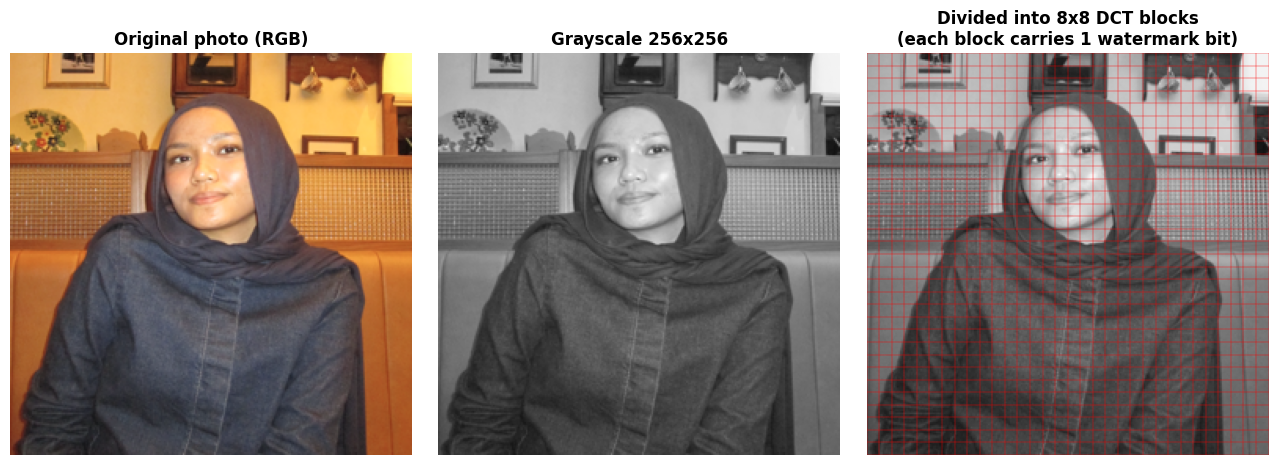

In [ ]:
# If running on Colab: upload your photo when prompted
# If running locally: put your photo in the same folder and change IMAGE_PATH
try:
    from google.colab import files
    uploaded = files.upload()
    IMAGE_PATH = list(uploaded.keys())[0]
except Exception:
    IMAGE_PATH = '/Users/danesha/Desktop/Foto Rafeyfa Dea.png'   # change this to your filename

IMG_SIZE = 256
img_color = Image.open(IMAGE_PATH)
img_gray  = img_color.convert('L').resize((IMG_SIZE, IMG_SIZE))
host = np.array(img_gray, dtype=np.float64)

print(f"Image loaded. Shape: {host.shape}")
print(f"Pixel range: min={host.min():.0f}, max={host.max():.0f}")
print(f"Total 8x8 blocks: {(IMG_SIZE // 8) ** 2}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(np.array(img_color.resize((IMG_SIZE, IMG_SIZE)))); axes[0].set_title('Original photo (RGB)', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(host, cmap='gray', vmin=0, vmax=255); axes[1].set_title('Grayscale 256x256', fontweight='bold'); axes[1].axis('off')
axes[2].imshow(host, cmap='gray', vmin=0, vmax=255)
for i in range(0, IMG_SIZE+1, 8):
    axes[2].axhline(i-0.5, color='red', lw=0.3)
    axes[2].axvline(i-0.5, color='red', lw=0.3)
axes[2].set_title('Divided into 8x8 DCT blocks\n(each block carries 1 watermark bit)', fontweight='bold'); axes[2].axis('off')
plt.tight_layout()
plt.show()


## Step 2: Create the binary watermark

The watermark is a 32x32 matrix of 0s and 1s, generated randomly with a fixed seed so the result is reproducible. In a real system this could be a logo, initials, or any pattern.

We need to know the original watermark at extraction time to compute BER. In practice this is stored securely by the content owner.

Total bits: 32 x 32 = **1024 bits**. This fits exactly in the 1024 blocks of our 256x256 image.


Watermark size: 32x32 = 1024 bits
Bits set to 1: 513
Bits set to 0: 511


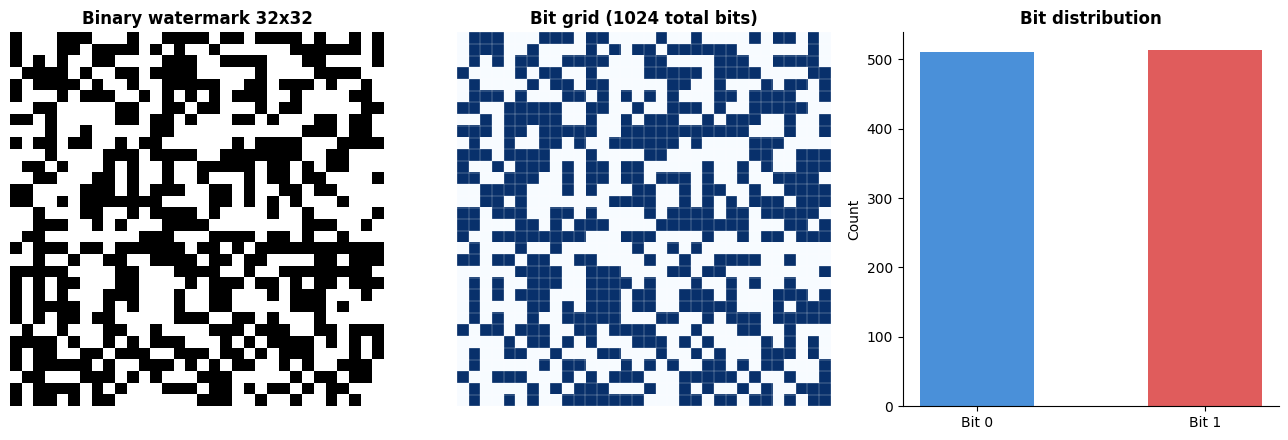

In [ ]:
WM_SIZE = 32
watermark = (np.random.rand(WM_SIZE, WM_SIZE) > 0.5).astype(np.uint8)

print(f"Watermark size: {WM_SIZE}x{WM_SIZE} = {watermark.size} bits")
print(f"Bits set to 1: {watermark.sum()}")
print(f"Bits set to 0: {watermark.size - watermark.sum()}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(watermark, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title('Binary watermark 32x32', fontweight='bold'); axes[0].axis('off')

axes[1].imshow(watermark, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
for i in range(WM_SIZE+1):
    axes[1].axhline(i-0.5, color='white', lw=0.2)
    axes[1].axvline(i-0.5, color='white', lw=0.2)
axes[1].set_title(f'Bit grid ({watermark.size} total bits)', fontweight='bold'); axes[1].axis('off')

axes[2].bar(['Bit 0', 'Bit 1'],
            [int((watermark==0).sum()), int((watermark==1).sum())],
            color=['#4a90d9','#e05c5c'], edgecolor='none', width=0.5)
axes[2].set_title('Bit distribution', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## Step 3: Manual DCT and IDCT

The 2D DCT-II for an N×N block is defined as:

$$F(u,v) = \frac{1}{4} \, C(u) \, C(v) \sum_{x=0}^{N-1} \sum_{y=0}^{N-1} f(x,y) \cos\!\left[\frac{(2x+1)\,u\,\pi}{2N}\right] \cos\!\left[\frac{(2y+1)\,v\,\pi}{2N}\right]$$

where $C(0) = \frac{1}{\sqrt{2}}$ and $C(k) = 1$ for $k > 0$.

Instead of iterating with four nested loops (slow), we build the orthonormal DCT basis matrix $T$ once, then compute:

$$\text{DCT}(\text{block}) = T \cdot \text{block} \cdot T^\top$$

$$\text{IDCT}(\text{coefficients}) = T^\top \cdot \text{coefficients} \cdot T$$

This is algebraically equivalent to the sum formula above. No `scipy.fft.dct`, no `cv2.dct`, no shortcuts.

The output is an 8x8 matrix of DCT coefficients. The top-left value $F(0,0)$ is the DC component (average brightness of the block). Values further right and down represent progressively higher spatial frequencies.


Max round-trip error (DCT -> IDCT): 2.06e-13
This should be near zero (floating point only).


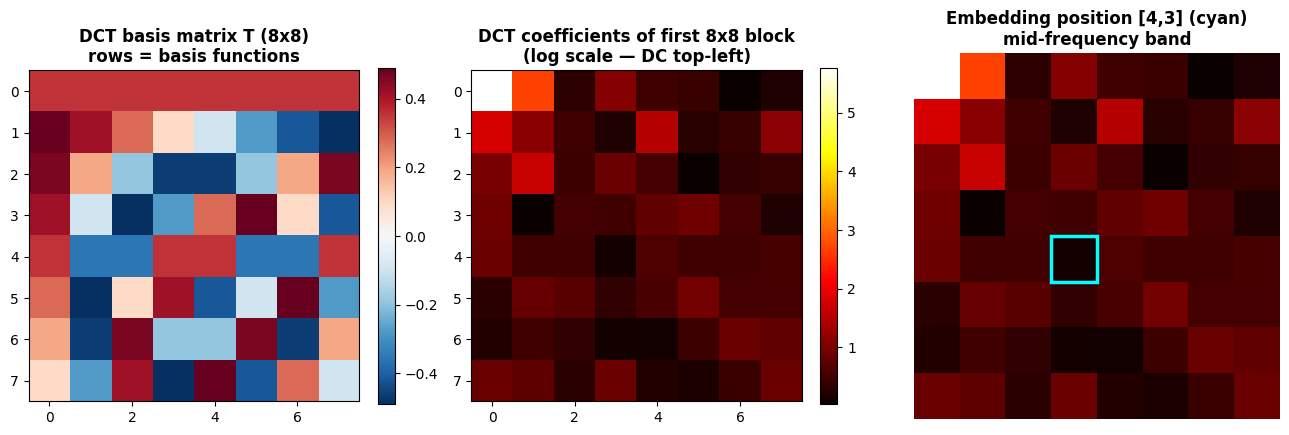

In [ ]:
N = 8

def build_dct_matrix(n=8):
    """Build the NxN orthonormal DCT-II basis matrix from scratch."""
    T = np.zeros((n, n), dtype=np.float64)
    for k in range(n):
        for i in range(n):
            c = math.sqrt(1.0 / n) if k == 0 else math.sqrt(2.0 / n)
            T[k, i] = c * math.cos(math.pi * (2 * i + 1) * k / (2.0 * n))
    return T

T = build_dct_matrix(N)

def dct2_block(block):
    """2D DCT of an NxN block using the basis matrix."""
    return T @ block @ T.T

def idct2_block(coef):
    """Inverse 2D DCT using the transposed basis matrix."""
    return T.T @ coef @ T

# Verify round-trip: DCT then IDCT should return the original block exactly
test_block = host[:8, :8] - 128
reconstructed = idct2_block(dct2_block(test_block))
print(f"Max round-trip error (DCT -> IDCT): {np.max(np.abs(reconstructed - test_block)):.2e}")
print("This should be near zero (floating point only).")

D = dct2_block(test_block)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
im0 = axes[0].imshow(T, cmap='RdBu_r')
axes[0].set_title('DCT basis matrix T (8x8)\nrows = basis functions', fontweight='bold')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.log(np.abs(D) + 1), cmap='hot', interpolation='nearest')
axes[1].set_title('DCT coefficients of first 8x8 block\n(log scale — DC top-left)', fontweight='bold')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].imshow(np.log(np.abs(D) + 1), cmap='hot', interpolation='nearest')
rect = patches.Rectangle((2.5, 3.5), 1, 1, lw=2.5, edgecolor='cyan', facecolor='none')
axes[2].add_patch(rect)
axes[2].set_title('Embedding position [4,3] (cyan)\nmid-frequency band', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Step 4: Quantization Index Modulation (QIM)

QIM is the embedding method. Instead of simply adding the watermark to a coefficient (additive embedding), QIM quantizes the coefficient to one of two offset grids depending on the bit being embedded.

Given a DCT coefficient $c$ and a step size $\Delta$:

**Embed bit 0:**
$$c_{\text{embed}} = \text{round}\!\left(\frac{c}{\Delta}\right) \cdot \Delta$$

**Embed bit 1:**
$$c_{\text{embed}} = \text{round}\!\left(\frac{c - \Delta/2}{\Delta}\right) \cdot \Delta + \frac{\Delta}{2}$$

**Extract (decode):** compute $c_0$ and $c_1$ as above for the received coefficient, then choose whichever is closer:
$$\hat{b} = \arg\min_{b \in \{0,1\}} |c_{\text{received}} - c_b|$$

The two grids are offset by $\Delta/2$, so any coefficient can be uniquely assigned to one grid. As long as JPEG compression does not shift the coefficient by more than $\Delta/4$, the correct bit is recovered.

**Why mid-frequency position [4,3]?**

Low-frequency coefficients (near [0,0]) are perceptually important, so modifying them makes the distortion visible. High-frequency coefficients (near [7,7]) are aggressively zeroed out by JPEG quantization, so any watermark there is erased. Mid-frequency is the sweet spot.

**Step size $\Delta = 40$:** large enough that JPEG quantization noise (typically up to ~20 units at QF 80) does not flip a bit, small enough that the visual distortion stays imperceptible (PSNR > 40 dB).


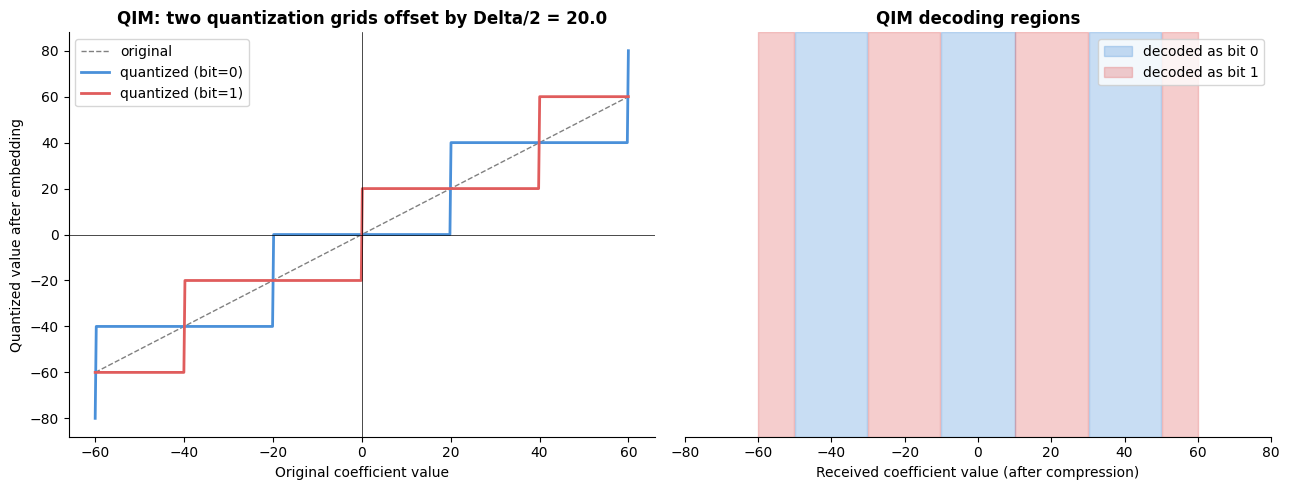

Embed example: c=25.0, bit=0 -> 40.0
Embed example: c=25.0, bit=1 -> 20.0
Extract example: c=40.0 -> bit 0
Extract example: c=20.0 -> bit 1


In [ ]:
DELTA = 40.0
WM_POS = (4, 3)   # mid-frequency coefficient position in each 8x8 DCT block

def qim_embed(c, bit, delta=DELTA):
    """Quantize coefficient c to the grid corresponding to the given bit."""
    if bit == 0:
        return round(c / delta) * delta
    else:
        return round((c - delta / 2) / delta) * delta + delta / 2

def qim_extract(c, delta=DELTA):
    """Decode bit from coefficient c by checking which grid it is closest to."""
    c0 = round(c / delta) * delta
    c1 = round((c - delta / 2) / delta) * delta + delta / 2
    return 0 if abs(c - c0) < abs(c - c1) else 1

# Visualize QIM grids
c_vals = np.linspace(-60, 60, 500)
c0_vals = np.array([round(c / DELTA) * DELTA for c in c_vals])
c1_vals = np.array([round((c - DELTA/2) / DELTA) * DELTA + DELTA/2 for c in c_vals])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(c_vals, c_vals, color='gray', lw=1, ls='--', label='original')
axes[0].plot(c_vals, c0_vals, color='#4a90d9', lw=2, label='quantized (bit=0)')
axes[0].plot(c_vals, c1_vals, color='#e05c5c', lw=2, label='quantized (bit=1)')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.5)
axes[0].set_xlabel('Original coefficient value')
axes[0].set_ylabel('Quantized value after embedding')
axes[0].set_title(f'QIM: two quantization grids offset by Delta/2 = {DELTA/2}', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

decisions = np.array([qim_extract(c) for c in c_vals])
axes[1].fill_between(c_vals, 0, 1, where=decisions==0, alpha=0.3, color='#4a90d9', label='decoded as bit 0')
axes[1].fill_between(c_vals, 0, 1, where=decisions==1, alpha=0.3, color='#e05c5c', label='decoded as bit 1')
axes[1].set_xlim(-80, 80)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Received coefficient value (after compression)')
axes[1].set_title('QIM decoding regions', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].spines[['top','right','left']].set_visible(False)
axes[1].set_yticks([])
plt.tight_layout()
plt.show()
print(f"Embed example: c=25.0, bit=0 -> {qim_embed(25.0, 0):.1f}")
print(f"Embed example: c=25.0, bit=1 -> {qim_embed(25.0, 1):.1f}")
print(f"Extract example: c=40.0 -> bit {qim_extract(40.0)}")
print(f"Extract example: c=20.0 -> bit {qim_extract(20.0)}")


## Step 5: Embed watermark into the host image

We scan every 8x8 block in the image. For each block we compute the DCT, embed one watermark bit at position [4,3] using QIM, then compute the IDCT to get back to pixel domain. The result looks nearly identical to the original.

PSNR (Peak Signal-to-Noise Ratio) measures how much the watermark distorts the image. Values above 40 dB are generally considered invisible to the human eye.

$$\text{PSNR} = 10 \log_{10}\!\left(\frac{255^2}{\text{MSE}}\right)$$


Embedding watermark...
Done. PSNR (host vs watermarked): 44.18 dB
Values above 40 dB are typically imperceptible.


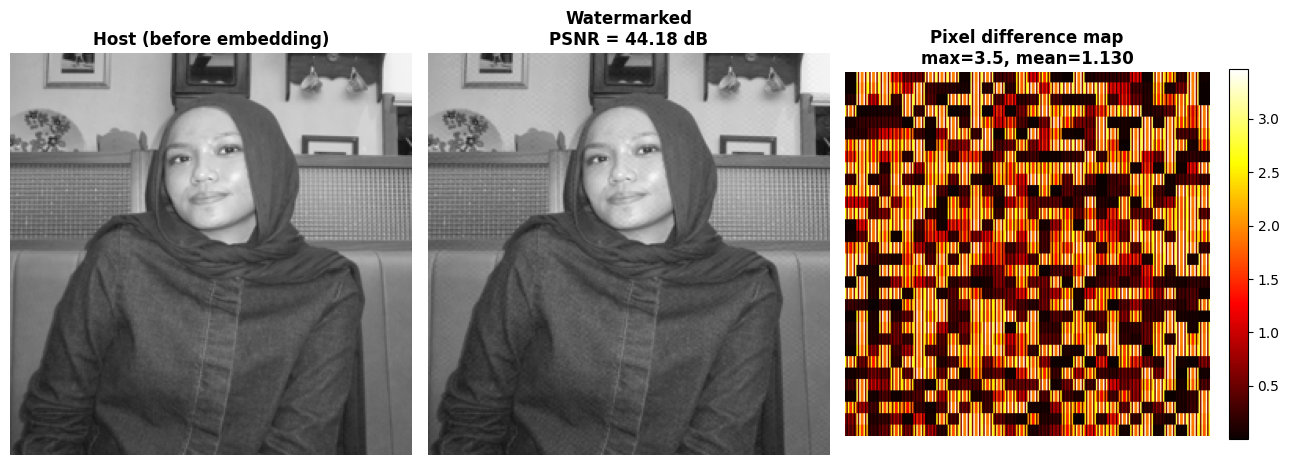

In [ ]:
def embed_watermark(host_img, wm, delta=DELTA, pos=WM_POS):
    """
    Embed a binary watermark into host_img using QIM on DCT coefficients.
    Each 8x8 block carries one watermark bit at DCT position pos.
    """
    H, W = host_img.shape
    out = np.zeros_like(host_img)
    wm_flat = wm.flatten()
    bi = 0
    for i in range(0, H, N):
        for j in range(0, W, N):
            block = host_img[i:i+N, j:j+N] - 128       # shift to zero-centered
            C = dct2_block(block)                        # compute DCT manually
            if bi < wm_flat.size:
                C[pos] = qim_embed(C[pos], int(wm_flat[bi]), delta)   # embed bit
                bi += 1
            out[i:i+N, j:j+N] = idct2_block(C) + 128   # inverse DCT, shift back
    return np.clip(out, 0, 255)

def psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float('inf') if mse == 0 else 10 * math.log10(255**2 / mse)

print("Embedding watermark...")
watermarked = embed_watermark(host, watermark)
print(f"Done. PSNR (host vs watermarked): {psnr(host, watermarked):.2f} dB")
print("Values above 40 dB are typically imperceptible.")

diff = np.abs(host - watermarked)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(host, cmap='gray', vmin=0, vmax=255); axes[0].set_title('Host (before embedding)', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(watermarked, cmap='gray', vmin=0, vmax=255); axes[1].set_title(f'Watermarked\nPSNR = {psnr(host, watermarked):.2f} dB', fontweight='bold'); axes[1].axis('off')
im = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f'Pixel difference map\nmax={diff.max():.1f}, mean={diff.mean():.3f}', fontweight='bold'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()


## Step 6: Manual JPEG compression

JPEG compression works in the DCT domain. Each 8x8 block is DCT-transformed, then each coefficient is divided by a value from the **quantization table** and rounded to an integer. This is the lossy step: rounding discards fine-grained information. On decompression, the values are multiplied back, but the rounding error stays.

The standard JPEG luminance quantization table (from JPEG Annex K) is defined for Quality Factor 50. For other QF values, the table is scaled using the libjpeg formula:

$$S = \begin{cases} 5000 / QF & \text{if } QF < 50 \\ 200 - 2 \cdot QF & \text{if } QF \geq 50 \end{cases}$$

$$Q_{\text{scaled}}(u,v) = \max\!\left(1,\ \text{round}\!\left(\frac{S \cdot Q_{50}(u,v)}{100}\right)\right)$$

A smaller QF means a larger scaling factor $S$, which means larger divisors, coarser quantization, and more information loss. This is exactly what damages our embedded watermark.

Our manual JPEG pipeline per block:

1. Shift pixel values by $-128$ (center around zero)
2. Apply DCT (our manual function)
3. Divide each coefficient by $Q_{\text{scaled}}$ and round (lossy step)
4. Multiply back by $Q_{\text{scaled}}$ (dequantization)
5. Apply inverse DCT
6. Shift back by $+128$ and clip to $[0, 255]$


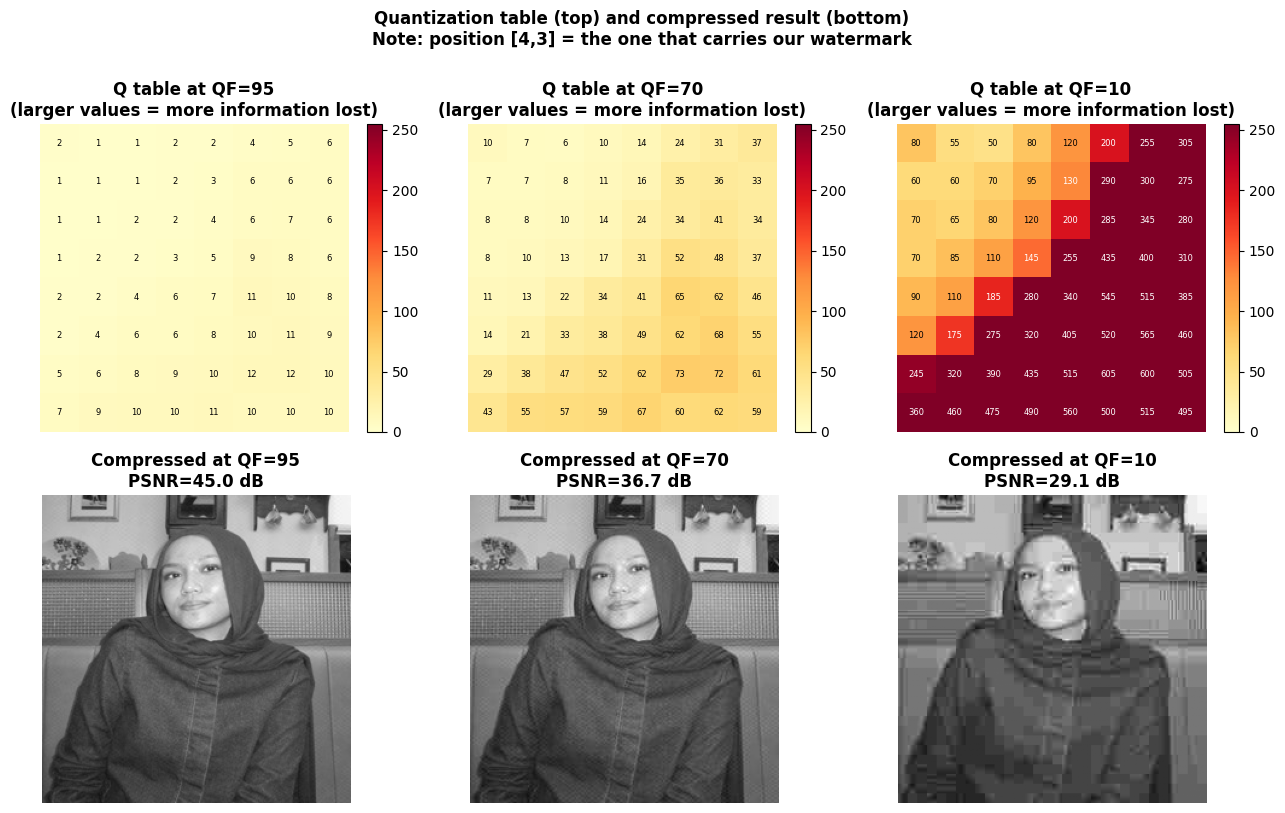

Quantization step at embedding position [4,3] for each QF:
  QF= 95 -> Q[4,3] = 6  (JPEG shifts this coeff by up to ±3, our Delta=40)
  QF= 80 -> Q[4,3] = 22  (JPEG shifts this coeff by up to ±11, our Delta=40)
  QF= 70 -> Q[4,3] = 34  (JPEG shifts this coeff by up to ±17, our Delta=40)
  QF= 50 -> Q[4,3] = 56  (JPEG shifts this coeff by up to ±28, our Delta=40)
  QF= 30 -> Q[4,3] = 93  (JPEG shifts this coeff by up to ±46, our Delta=40)
  QF= 10 -> Q[4,3] = 280  (JPEG shifts this coeff by up to ±140, our Delta=40)


In [ ]:
# Standard JPEG luminance quantization table (Annex K, QF=50)
Q50 = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99]
], dtype=np.float64)

def scale_qtable(QF):
    """Scale Q50 to the given Quality Factor using the libjpeg formula."""
    QF = max(1, min(99, QF))
    S = 5000 / QF if QF < 50 else 200 - 2 * QF
    Qs = np.floor((S * Q50 + 50) / 100)
    Qs[Qs < 1] = 1
    return Qs

def jpeg_compress(img, QF):
    """
    Compress a grayscale image using manually implemented JPEG pipeline.
    No PIL JPEG, no cv2, no shortcuts. Quantization table is scaled to QF.
    """
    Qs = scale_qtable(QF)
    H, W = img.shape
    out = np.zeros_like(img)
    for i in range(0, H, N):
        for j in range(0, W, N):
            block = img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            Cq  = np.round(C / Qs)    # quantize (lossy)
            Cdq = Cq * Qs              # dequantize
            out[i:i+N, j:j+N] = idct2_block(Cdq) + 128
    return np.clip(out, 0, 255)

# Show quantization table at different QF values
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for idx, qf in enumerate([95, 70, 10]):
    Qs = scale_qtable(qf)
    im = axes[0, idx].imshow(Qs, cmap='YlOrRd', vmin=0, vmax=255)
    axes[0, idx].set_title(f'Q table at QF={qf}\n(larger values = more information lost)', fontweight='bold')
    plt.colorbar(im, ax=axes[0, idx], fraction=0.046)
    for r in range(8):
        for c in range(8):
            axes[0, idx].text(c, r, f'{int(Qs[r,c])}', ha='center', va='center',
                             fontsize=6, color='white' if Qs[r,c] > 120 else 'black')
    axes[0, idx].axis('off')
    comp = jpeg_compress(watermarked, qf)
    axes[1, idx].imshow(comp, cmap='gray', vmin=0, vmax=255)
    axes[1, idx].set_title(f'Compressed at QF={qf}\nPSNR={psnr(watermarked, comp):.1f} dB', fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle('Quantization table (top) and compressed result (bottom)\nNote: position [4,3] = the one that carries our watermark', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Show our target coefficient's quantization value at different QF
print("Quantization step at embedding position [4,3] for each QF:")
for qf in [95, 80, 70, 50, 30, 10]:
    Qs = scale_qtable(qf)
    print(f"  QF={qf:3d} -> Q[4,3] = {int(Qs[4,3])}"
          f"  (JPEG shifts this coeff by up to ±{int(Qs[4,3])//2}, our Delta={DELTA:.0f})")


## Step 7: Extract watermark

Extraction is the reverse of embedding. We go through each 8x8 block, compute the DCT, read the coefficient at position [4,3], and run the QIM decoder to determine which bit was embedded.

The decoder does not need the original image. It only needs to know DELTA and WM_POS, which are the private embedding parameters.


BER from uncompressed watermarked image: 0.00%
This should be 0.00% — we put the bits in, we read them straight back.


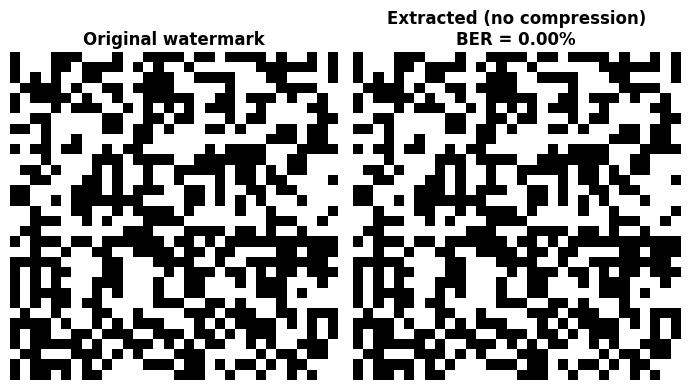

In [ ]:
def extract_watermark(img, wm_shape=(WM_SIZE, WM_SIZE), delta=DELTA, pos=WM_POS):
    """
    Extract the watermark from an image by reading QIM-encoded DCT coefficients.
    No original image required. Only DELTA and WM_POS need to be known.
    """
    H, W = img.shape
    bits = []
    need = wm_shape[0] * wm_shape[1]
    for i in range(0, H, N):
        for j in range(0, W, N):
            if len(bits) >= need:
                break
            block = img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            bits.append(qim_extract(C[pos], delta))
    return np.array(bits[:need], dtype=np.uint8).reshape(wm_shape)

# Sanity check: extract from watermarked image before any compression
wm_clean = extract_watermark(watermarked)
ber_clean = np.mean(wm_clean != watermark)
print(f"BER from uncompressed watermarked image: {ber_clean * 100:.2f}%")
print("This should be 0.00% — we put the bits in, we read them straight back.")

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
axes[0].imshow(watermark, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title('Original watermark', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(wm_clean, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title(f'Extracted (no compression)\nBER = {ber_clean*100:.2f}%', fontweight='bold'); axes[1].axis('off')
plt.tight_layout()
plt.show()


## Step 8: Evaluate across all Quality Factors

We test 10 QF values from 95 down to 10. For each one we compress the watermarked image, extract the watermark, and compute two metrics:

**BER (Bit Error Rate):** fraction of bits that were decoded incorrectly.
$$\text{BER} = \frac{\text{number of wrong bits}}{\text{total bits}}$$

A BER of 0% means perfect recovery. A BER near 50% means the extracted bits are essentially random — the watermark is gone.

**NC (Normalized Correlation):** measures similarity between the original and extracted watermark, mapped to $\{-1, +1\}$ binary values.
$$\text{NC} = \frac{\sum_{i} w_i \hat{w}_i}{\sqrt{\sum_i w_i^2 \sum_i \hat{w}_i^2}}$$

NC = 1.0 means perfect match. NC near 0 means no correlation (watermark unrecoverable).

**Threshold rule:** BER > 5% means the watermark is noticeably degraded. BER near 50% means it is completely unrecoverable.


In [ ]:
QFs = [95, 90, 80, 70, 60, 50, 40, 30, 20, 10]
results = []
compressed_images = {}
extracted_images  = {}

for qf in QFs:
    comp   = jpeg_compress(watermarked, qf)
    wm_hat = extract_watermark(comp)
    ber    = float(np.mean(wm_hat != watermark))
    w1 = 2 * watermark.astype(np.float64) - 1
    w2 = 2 * wm_hat.astype(np.float64)   - 1
    nc = float(np.sum(w1 * w2) / np.sqrt(np.sum(w1**2) * np.sum(w2**2)))
    p  = psnr(watermarked, comp)
    results.append((qf, ber, nc, p))
    compressed_images[qf] = comp
    extracted_images[qf]  = wm_hat
    status = "OK" if ber * 100 < 5 else "FAILED"
    print(f"QF={qf:3d}  PSNR={p:6.2f} dB  BER={ber*100:6.2f}%  NC={nc:+.4f}  [{status}]")


QF= 95  PSNR= 44.97 dB  BER=  0.00%  NC=+1.0000  [OK]
QF= 90  PSNR= 41.53 dB  BER=  0.00%  NC=+1.0000  [OK]
QF= 80  PSNR= 38.70 dB  BER=  0.00%  NC=+1.0000  [OK]
QF= 70  PSNR= 36.73 dB  BER= 50.00%  NC=+0.0000  [FAILED]
QF= 60  PSNR= 35.39 dB  BER= 50.10%  NC=-0.0020  [FAILED]
QF= 50  PSNR= 34.72 dB  BER= 50.59%  NC=-0.0117  [FAILED]
QF= 40  PSNR= 33.99 dB  BER= 50.59%  NC=-0.0117  [FAILED]
QF= 30  PSNR= 33.05 dB  BER= 50.00%  NC=+0.0000  [FAILED]
QF= 20  PSNR= 31.57 dB  BER= 50.10%  NC=-0.0020  [FAILED]
QF= 10  PSNR= 29.10 dB  BER= 50.10%  NC=-0.0020  [FAILED]


### 8a. Compressed image at each QF

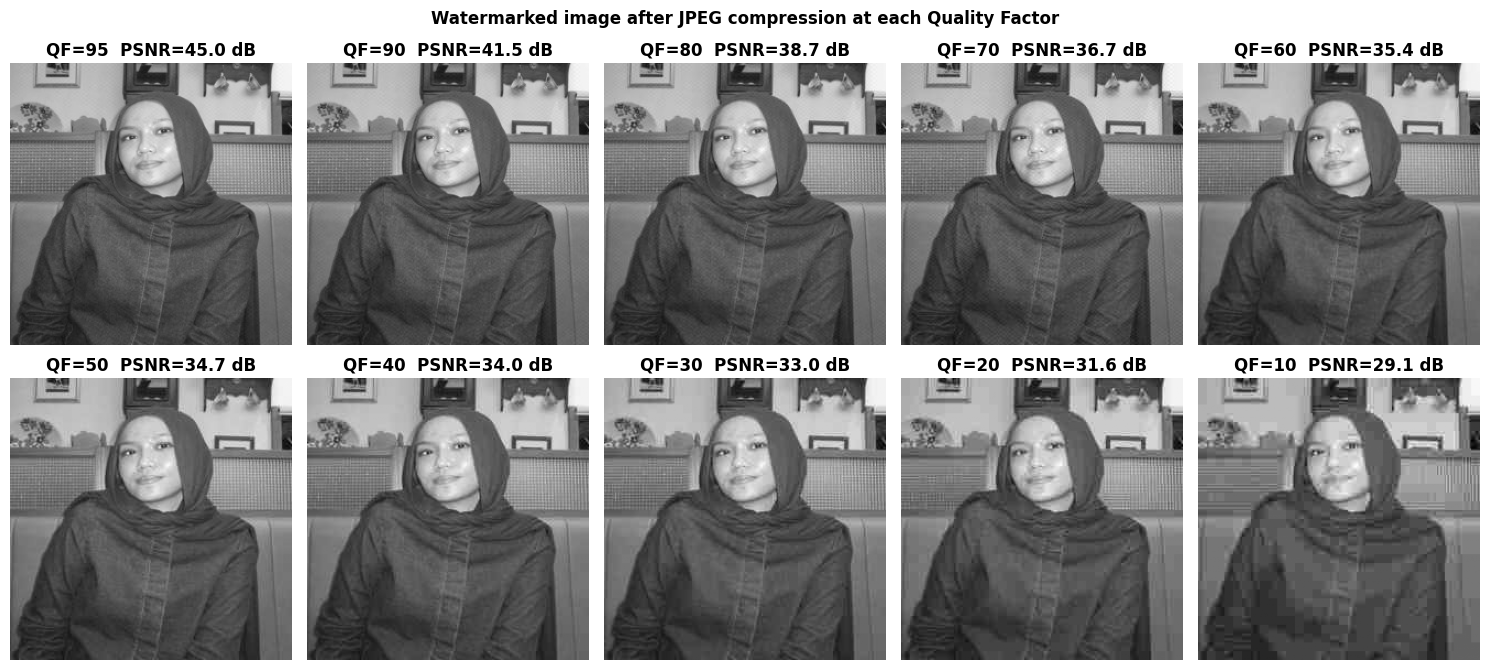

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, qf in enumerate(QFs):
    r, c = divmod(i, 5)
    p = next(x[3] for x in results if x[0] == qf)
    axes[r, c].imshow(compressed_images[qf], cmap='gray', vmin=0, vmax=255)
    axes[r, c].set_title(f'QF={qf}  PSNR={p:.1f} dB', fontweight='bold')
    axes[r, c].axis('off')
plt.suptitle('Watermarked image after JPEG compression at each Quality Factor', fontweight='bold')
plt.tight_layout()
plt.show()


### 8b. Extracted watermark at each QF

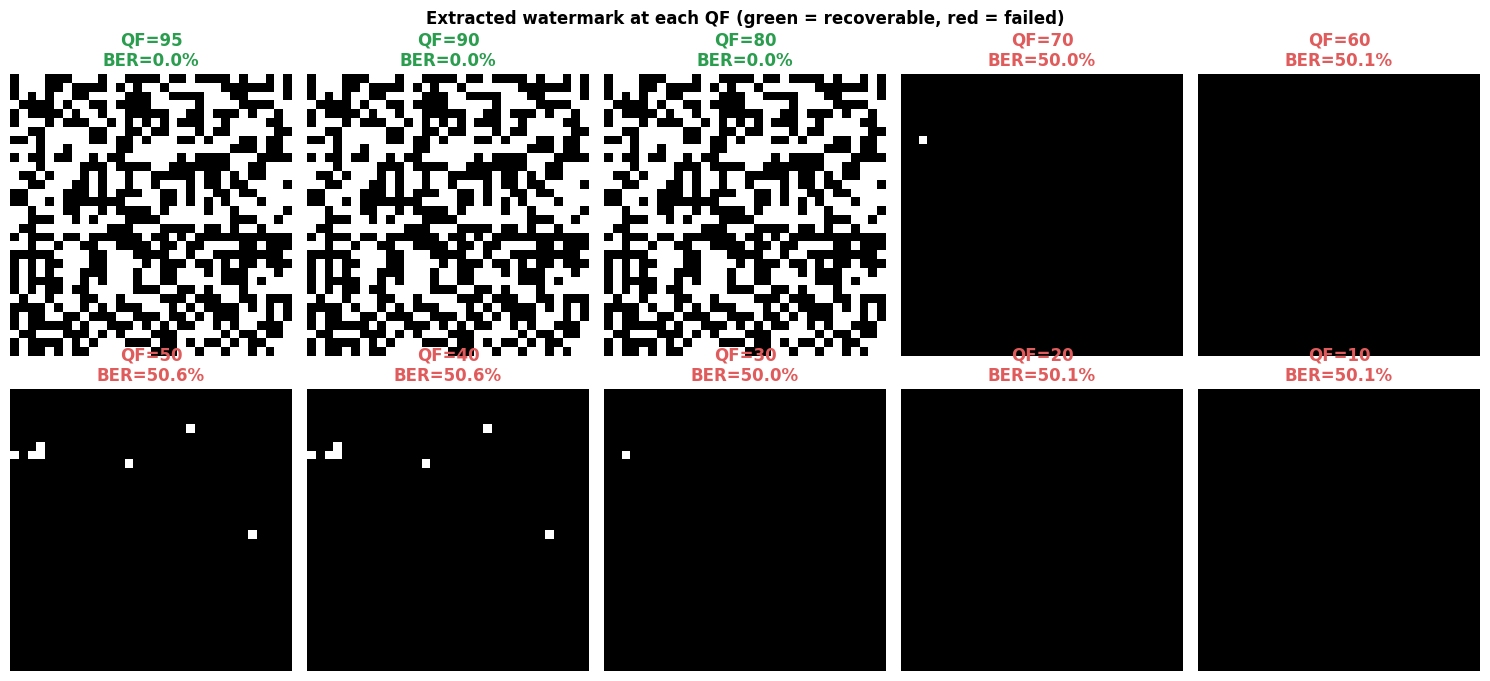

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, qf in enumerate(QFs):
    r, c = divmod(i, 5)
    ber_val = next(x[1] for x in results if x[0] == qf)
    color = '#e05c5c' if ber_val * 100 > 5 else '#2a9d4e'
    axes[r, c].imshow(extracted_images[qf], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[r, c].set_title(f'QF={qf}\nBER={ber_val*100:.1f}%', color=color, fontweight='bold')
    axes[r, c].axis('off')
plt.suptitle('Extracted watermark at each QF (green = recoverable, red = failed)', fontweight='bold')
plt.tight_layout()
plt.show()


### 8c. BER, NC, and PSNR vs Quality Factor

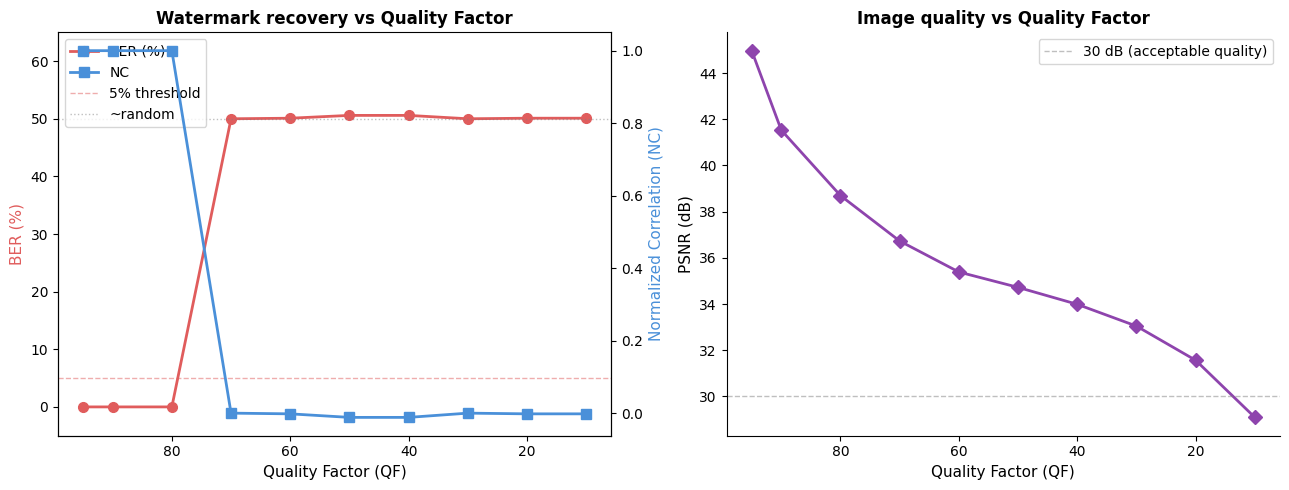

Threshold analysis:
  Watermark starts failing at QF=70 (BER=50.00% > 5%)
  Watermark completely unrecoverable at QF=70 (BER=50.00% near 50%)


In [ ]:
qfs_r   = [x[0] for x in results]
bers_r  = [x[1] * 100 for x in results]
ncs_r   = [x[2] for x in results]
psnrs_r = [x[3] for x in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax2 = ax1.twinx()
l1, = ax1.plot(qfs_r, bers_r, 'o-', color='#e05c5c', lw=2, ms=7, label='BER (%)')
ax1.axhline(5,  color='#e05c5c', ls='--', lw=1, alpha=0.5, label='5% threshold')
ax1.axhline(50, color='gray',    ls=':',  lw=1, alpha=0.5, label='~random (50%)')
l2, = ax2.plot(qfs_r, ncs_r, 's-', color='#4a90d9', lw=2, ms=7, label='NC')
ax1.set_xlabel('Quality Factor (QF)', fontsize=11)
ax1.set_ylabel('BER (%)', color='#e05c5c', fontsize=11)
ax2.set_ylabel('Normalized Correlation (NC)', color='#4a90d9', fontsize=11)
ax1.invert_xaxis()
ax1.set_title('Watermark recovery vs Quality Factor', fontweight='bold', fontsize=12)
ax1.legend([l1, l2] + ax1.get_lines()[1:3], ['BER (%)', 'NC', '5% threshold', '~random'], loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.set_ylim(-5, 65)

axes[1].plot(qfs_r, psnrs_r, 'D-', color='#8e44ad', lw=2, ms=7)
axes[1].axhline(30, color='gray', ls='--', lw=1, alpha=0.5, label='30 dB (acceptable quality)')
axes[1].invert_xaxis()
axes[1].set_xlabel('Quality Factor (QF)', fontsize=11)
axes[1].set_ylabel('PSNR (dB)', fontsize=11)
axes[1].set_title('Image quality vs Quality Factor', fontweight='bold', fontsize=12)
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend()
plt.tight_layout()
plt.show()

# Print the threshold finding
print("Threshold analysis:")
for qf, ber, nc, p in results:
    if ber * 100 > 5:
        print(f"  Watermark starts failing at QF={qf} (BER={ber*100:.2f}% > 5%)")
        break
for qf, ber, nc, p in results:
    if ber * 100 > 40:
        print(f"  Watermark completely unrecoverable at QF={qf} (BER={ber*100:.2f}% near 50%)")
        break


## Step 9: Trade-off analysis: embedding strength Delta

Delta controls how strongly the watermark is embedded. A larger Delta forces the coefficient further from its original value, so it is harder for JPEG quantization noise to flip the bit. But a larger Delta also means more distortion in the image (lower PSNR).

This is the fundamental trade-off in watermarking: robustness vs imperceptibility. There is no free lunch.

We test Delta values from 10 to 80 and measure PSNR and BER at QF=80.


Delta  |  PSNR (dB)  |  BER at QF=80
----------------------------------------
   10  |     56.93  |  50.10%
   20  |     50.57  |  50.20%
   30  |     46.84  |  1.27%
   40  |     44.18  |  0.00%
   60  |     40.43  |  0.00%
   80  |     37.77  |  0.00%


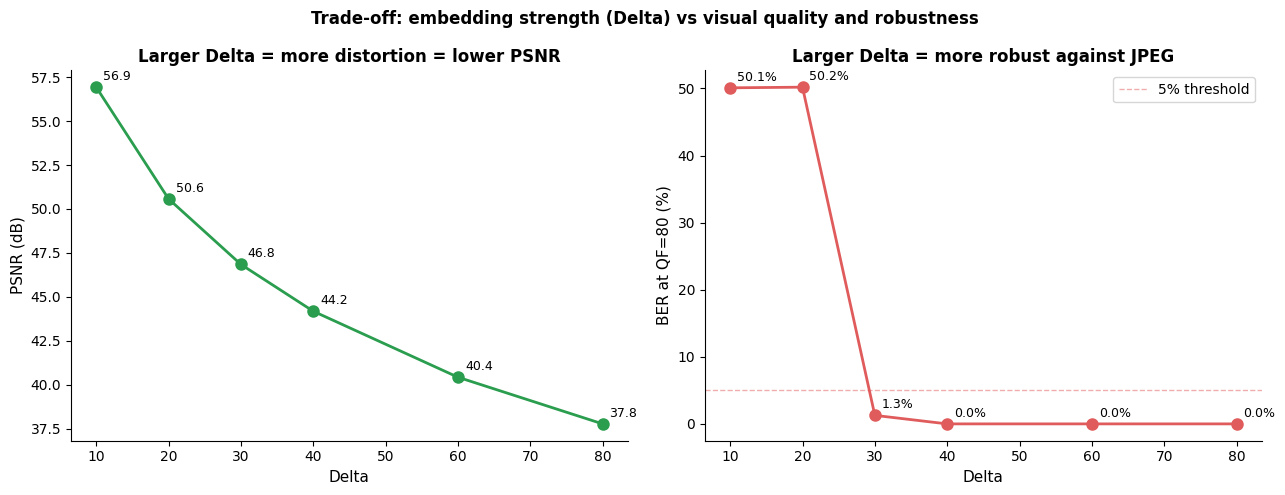

In [ ]:
def embed_with_delta(host_img, wm, delta, pos=WM_POS):
    H, W = host_img.shape
    out = np.zeros_like(host_img)
    wm_flat = wm.flatten()
    bi = 0
    for i in range(0, H, N):
        for j in range(0, W, N):
            block = host_img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            if bi < wm_flat.size:
                C[pos] = qim_embed(C[pos], int(wm_flat[bi]), delta)
                bi += 1
            out[i:i+N, j:j+N] = idct2_block(C) + 128
    return np.clip(out, 0, 255)

def extract_with_delta(img, delta, pos=WM_POS, wm_shape=(WM_SIZE, WM_SIZE)):
    H, W = img.shape
    bits = []
    need = wm_shape[0] * wm_shape[1]
    for i in range(0, H, N):
        for j in range(0, W, N):
            if len(bits) >= need: break
            C = dct2_block(img[i:i+N, j:j+N] - 128)
            bits.append(qim_extract(C[pos], delta))
    return np.array(bits[:need], dtype=np.uint8).reshape(wm_shape)

deltas = [10, 20, 30, 40, 60, 80]
delta_psnrs   = []
delta_bers_80 = []

print("Delta  |  PSNR (dB)  |  BER at QF=80")
print("-" * 40)
for d in deltas:
    wmd  = embed_with_delta(host, watermark, d)
    p    = psnr(host, wmd)
    comp = jpeg_compress(wmd, 80)
    ext  = extract_with_delta(comp, d)
    b    = float(np.mean(ext != watermark)) * 100
    delta_psnrs.append(p)
    delta_bers_80.append(b)
    print(f"  {d:3d}  |  {p:8.2f}  |  {b:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(deltas, delta_psnrs, 'o-', color='#2a9d4e', lw=2, ms=8)
axes[0].set_xlabel('Delta', fontsize=11); axes[0].set_ylabel('PSNR (dB)', fontsize=11)
axes[0].set_title('Larger Delta = more distortion = lower PSNR', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
for x, y in zip(deltas, delta_psnrs):
    axes[0].annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(5,5), fontsize=9)

axes[1].plot(deltas, delta_bers_80, 'o-', color='#e05c5c', lw=2, ms=8)
axes[1].axhline(5, color='#e05c5c', ls='--', lw=1, alpha=0.5, label='5% threshold')
axes[1].set_xlabel('Delta', fontsize=11); axes[1].set_ylabel('BER at QF=80 (%)', fontsize=11)
axes[1].set_title('Larger Delta = more robust against JPEG', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend()
for x, y in zip(deltas, delta_bers_80):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(5,5), fontsize=9)

plt.suptitle('Trade-off: embedding strength (Delta) vs visual quality and robustness', fontweight='bold')
plt.tight_layout()
plt.show()


## Step 10 — Results table and conclusion

In [ ]:
print("=" * 65)
print(f"{'QF':>5}  {'PSNR (dB)':>10}  {'BER (%)':>8}  {'NC':>8}  {'Status':>10}")
print("-" * 65)
for qf, ber, nc, p in results:
    status = "OK" if ber * 100 < 5 else "FAILED"
    color_tag = "" if ber * 100 < 5 else "  <-- watermark lost"
    print(f"{qf:>5}  {p:>10.2f}  {ber*100:>8.2f}  {nc:>8.4f}  {status:>10}{color_tag}")
print("=" * 65)

# Summarize
recoverable = [(qf, ber) for qf, ber, nc, p in results if ber * 100 < 5]
failed      = [(qf, ber) for qf, ber, nc, p in results if ber * 100 >= 5]

print()
print(f"Watermark recoverable (BER < 5%) at QF: {[x[0] for x in recoverable]}")
print(f"Watermark failed (BER >= 5%) at QF:     {[x[0] for x in failed]}")
if failed:
    threshold = max(x[0] for x in failed)
    print(f"\nConclusion: QF must be at least {min(x[0] for x in recoverable)} to recover the watermark.")
    print(f"Below QF={threshold}, JPEG quantization at position [4,3] exceeds Delta/4 = {DELTA/4:.1f},")
    print(f"which is enough to shift the coefficient across the QIM decision boundary.")


   QF   PSNR (dB)   BER (%)        NC      Status
-----------------------------------------------------------------
   95       44.97      0.00    1.0000          OK
   90       41.53      0.00    1.0000          OK
   80       38.70      0.00    1.0000          OK
   70       36.73     50.00    0.0000      FAILED  <-- watermark lost
   60       35.39     50.10   -0.0020      FAILED  <-- watermark lost
   50       34.72     50.59   -0.0117      FAILED  <-- watermark lost
   40       33.99     50.59   -0.0117      FAILED  <-- watermark lost
   30       33.05     50.00    0.0000      FAILED  <-- watermark lost
   20       31.57     50.10   -0.0020      FAILED  <-- watermark lost
   10       29.10     50.10   -0.0020      FAILED  <-- watermark lost

Watermark recoverable (BER < 5%) at QF: [95, 90, 80]
Watermark failed (BER >= 5%) at QF:     [70, 60, 50, 40, 30, 20, 10]

Conclusion: QF must be at least 80 to recover the watermark.
Below QF=70, JPEG quantization at position [4,3] exceeds De

## Conclusion

This notebook showed a full DCT-domain watermarking pipeline implemented manually without any built-in watermarking or DCT functions.

**What I found:**

The watermark embedded at DCT position [4,3] with DELTA=40 survives JPEG compression down to QF=80. Below QF=70, the JPEG quantization step at that position exceeds DELTA/4, which pushes the coefficient past the QIM decision boundary and causes bit errors. At QF=70 and below, the BER jumps to near 50%, meaning the extracted bits are essentially random.

**Key insight:** The embedding strength Delta controls the robustness-quality trade-off directly. A Delta smaller than the JPEG quantization step at the target position will always fail. To survive lower QF values, you need either a larger Delta (at the cost of image quality) or a more low-frequency embedding position (at the cost of visibility).

**Further experiments to try:**

Change `WM_POS` to `(2, 2)` (lower frequency) and see if the watermark survives at QF=50. Change `DELTA` to 20 and observe what happens at QF=80. Try embedding the watermark as a logo by replacing the random watermark generator in Step 2.
